# 12. GARCH model — all years (Method #2)
The walk-forward for GARCH: one estimation per year, 2007–2023, with a `for` loop — the same idea as notebook 10.

* **Needs:** `work/dataset.csv`. **Makes:** `work/garch_forecasts.csv`.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

In [ ]:
!pip install -q arch

In [3]:
from pandas import read_csv
dataset = read_csv(folder + 'work/dataset.csv', index_col=0, parse_dates=True)
dataset = dataset.loc[:'2023-08-31']        # main sample
print(dataset.shape)

(5243, 17)


In [4]:
returns = dataset['ret'].dropna() * 100

In [5]:
from arch import arch_model
forecasts = []
years = []
persistence = []
tails = []

for year in range(2007, 2024):
    test_days = dataset.loc[str(year) + '-01-01':str(year) + '-12-31'].dropna(subset=['rv5_fwd']).index

    GARCH_model = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='t')   # building
    GARCH_fit = GARCH_model.fit(last_obs=str(year) + '-01-01', disp='off')                # training
    forecast = GARCH_fit.forecast(horizon=5, start=test_days[0], reindex=False)          # testing
    y_pred = forecast.variance.loc[test_days].sum(axis=1) / 10000

    forecasts.append(y_pred)
    years.append(year)
    persistence.append(GARCH_fit.params['alpha[1]'] + GARCH_fit.params['beta[1]'])
    tails.append(GARCH_fit.params['nu'])
    print(year, ': alpha + beta =', round(persistence[-1], 3), '| nu =', round(tails[-1], 1))

2007 : alpha + beta = 0.957 | nu = 6.2
2008 : alpha + beta = 0.977 | nu = 6.2


2009 : alpha + beta = 0.994 | nu = 6.5
2010 : alpha + beta = 0.999 | nu = 7.0


2011 : alpha + beta = 0.998 | nu = 6.8
2012 : alpha + beta = 0.999 | nu = 7.3


2013 : alpha + beta = 0.997 | nu = 7.7
2014 : alpha + beta = 0.996 | nu = 7.8


2015 : alpha + beta = 0.995 | nu = 8.2
2016 : alpha + beta = 0.995 | nu = 8.3


2017 : alpha + beta = 0.992 | nu = 7.7
2018 : alpha + beta = 0.991 | nu = 7.7


2019 : alpha + beta = 0.99 | nu = 7.8
2020 : alpha + beta = 0.989 | nu = 8.0


2021 : alpha + beta = 0.99 | nu = 7.7
2022 : alpha + beta = 0.989 | nu = 7.3
2023 : alpha + beta = 0.99 | nu = 7.4


In [6]:
from pandas import concat, DataFrame
garch = concat(forecasts)
print(len(garch), 'forecast days')
DataFrame({'test year': years, 'alpha + beta': persistence, 'nu (tails)': tails}).round(3)

4230 forecast days


,test year,alpha + beta,nu (tails)
0,2007,0.957,6.202
1,2008,0.977,6.225
2,2009,0.994,6.534
3,2010,0.999,7.011
4,2011,0.998,6.830
5,2012,0.999,7.348
6,2013,0.997,7.703
7,2014,0.996,7.843
8,2015,0.995,8.208
9,2016,0.995,8.282


Persistence stays between about 0.96 and 0.999: shocks to Irish volatility fade slowly. `nu` between 6 and 8 means fatter tails than a bell curve.

In [7]:
saved = read_csv(folder + 'results/benchmark_forecasts.csv', index_col=0, parse_dates=True)
print('largest difference from the saved GARCH forecasts:', (garch - saved['GARCH']).abs().max())
DataFrame({'GARCH': garch}).to_csv(folder + 'work/garch_forecasts.csv')

largest difference from the saved GARCH forecasts: 9.996344030316351e-17


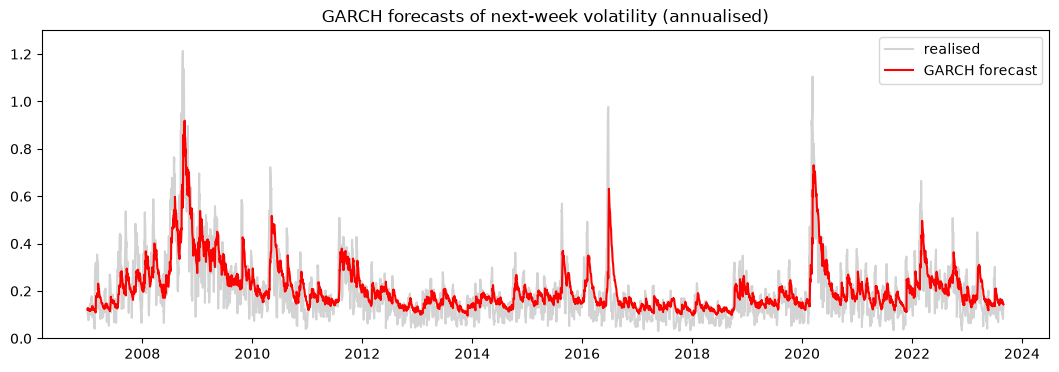

In [8]:
from numpy import sqrt
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 4))
plt.plot(sqrt(dataset.loc[garch.index, 'rv5_fwd'] * 252 / 5), color='lightgrey', label='realised')
plt.plot(sqrt(garch * 252 / 5), color='red', label='GARCH forecast')
plt.ylim(0, 1.3)
plt.legend()
plt.title('GARCH forecasts of next-week volatility (annualised)')
plt.show()